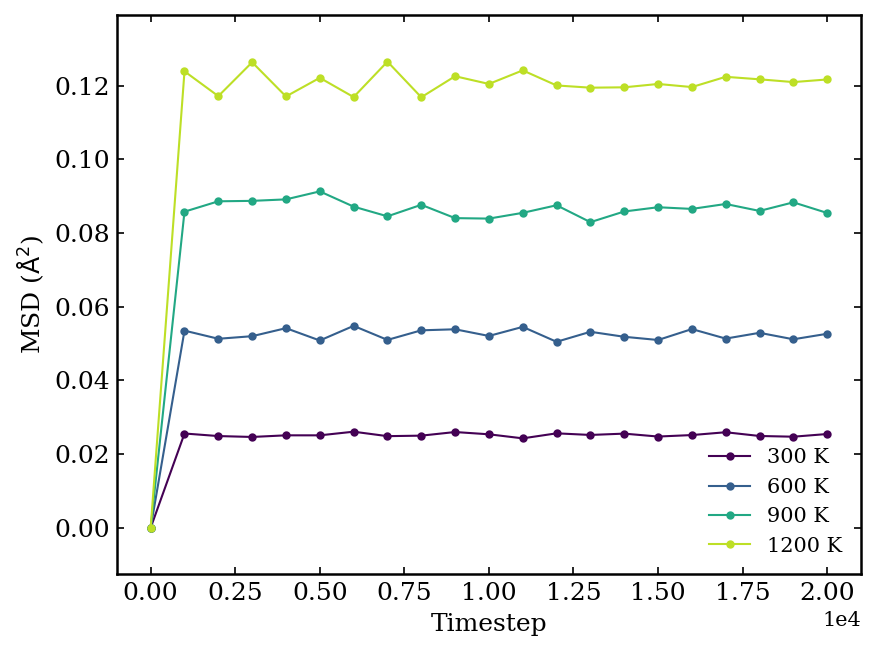

In [2]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter


# Find all MSD_*.dat files and sort them numerically by temperature
files = glob.glob("MSD_*K.dat")

def extract_temp(filepath):
    match = re.search(r"MSD_(\d+)K", os.path.basename(filepath))
    return int(match.group(1)) if match else 0

files.sort(key=extract_temp)

if not files:
    print("No MSD files found!")

plt.rcParams.update({
    "font.size": 12,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=150)

# Use a colormap so colors scale nicely regardless of how many files you have
colors = plt.cm.viridis(np.linspace(0, 0.9, len(files)))

for filepath, color in zip(files, colors):
    data = np.loadtxt(filepath, comments="#")

    x = data[:, 0]
    y = data[:, 1]

    temp = extract_temp(filepath)

    ax.plot(
        x,
        y,
        marker="o",
        markersize=3,
        linewidth=1,
        color=color,
        linestyle="-",
        label=f"{temp} K",
    )

ax.set_xlabel("Timestep")
ax.set_ylabel(r"MSD ($\mathrm{\AA}^2$)")

ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
ax.xaxis.get_offset_text().set_fontsize(10)

ax.margins(x=0.05, y=0.1)
ax.legend(frameon=False, fontsize=10)

fig.tight_layout()
fig.savefig("MSD_all.png", dpi=300)
fig.savefig("MSD_all.pdf")

plt.show()